In [1]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from pyomo.environ import SolverFactory, value
import matplotlib as mpl

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('ProCatPy'), '..'))
sys.path.insert(0, parent_dir)
from ProCatPy.ProCatSystem import ProCatModel
#from ProCatPy.ProCatOpt import ProCatBO

import warnings
warnings.filterwarnings("ignore")

C:\Users\jflory\AppData\Local\anaconda3\envs\CatEnvBackup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Establish baseline energy params
seed = 7
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

ebounds = np.array([[0.8],[1.6]]).reshape(2)
BEParams = np.array([[2],
                     [1.4]])
EaParams = np.array([[0.6],
                     [1]])
no = 51

In [3]:
# Set up tracking variables
Offsets = np.linspace(ebounds[0],ebounds[1],no).reshape(-1)
ystaticBg = np.zeros([no])
yA = np.zeros([no])
yB = np.zeros([no])

sX = np.zeros(1)
sy = np.zeros(1)

In [4]:
# Run simulations
ns=1
dcn = ProCatModel(BEParams,EaParams)
dcn.SetEnergyParams(ebounds,ns,'Square')

# Simulate Model
for i in range(no):

    eparams = {'Amplitude':[0.0],
           'DutyCycle':[0.0],
           'Frequency':[1e-2],
           'Offset': Offsets[i],
           }

    print(f'Iter {i+1:3.0f}/{no}| Offset: {Offsets[i]:5.3f} eV')
    dcn.SetSignalParams(eparams,False)
    dcn.solveBVP(1)
    ystaticBg[i] = dcn.calc_TOF(dcn.CBg)
    yA[i] = dcn.CA[0]
    yB[i] = dcn.CB[0]

sindex = np.argmax(ystaticBg)
sX = Offsets[sindex]
sy = ystaticBg[sindex]
print(sy)

Iter   1/51| Offset: 0.800 eV
Iter   2/51| Offset: 0.816 eV
Iter   3/51| Offset: 0.832 eV
Iter   4/51| Offset: 0.848 eV
Iter   5/51| Offset: 0.864 eV
Iter   6/51| Offset: 0.880 eV
Iter   7/51| Offset: 0.896 eV
Iter   8/51| Offset: 0.912 eV
Iter   9/51| Offset: 0.928 eV
Iter  10/51| Offset: 0.944 eV
Iter  11/51| Offset: 0.960 eV
Iter  12/51| Offset: 0.976 eV
Iter  13/51| Offset: 0.992 eV
Iter  14/51| Offset: 1.008 eV
Iter  15/51| Offset: 1.024 eV
Iter  16/51| Offset: 1.040 eV
Iter  17/51| Offset: 1.056 eV
Iter  18/51| Offset: 1.072 eV
Iter  19/51| Offset: 1.088 eV
Iter  20/51| Offset: 1.104 eV
Iter  21/51| Offset: 1.120 eV
Iter  22/51| Offset: 1.136 eV
Iter  23/51| Offset: 1.152 eV
Iter  24/51| Offset: 1.168 eV
Iter  25/51| Offset: 1.184 eV
Iter  26/51| Offset: 1.200 eV
Iter  27/51| Offset: 1.216 eV
Iter  28/51| Offset: 1.232 eV
Iter  29/51| Offset: 1.248 eV
Iter  30/51| Offset: 1.264 eV
Iter  31/51| Offset: 1.280 eV
Iter  32/51| Offset: 1.296 eV
Iter  33/51| Offset: 1.312 eV
Iter  34/5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


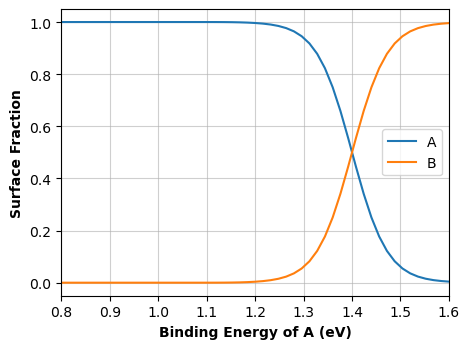

In [5]:
width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
ax.plot(Offsets,yA)
ax.plot(Offsets,yB)
ax.legend(['A','B'],fontsize = 10)
ax.set_xlabel('Binding Energy of A (eV)', weight = 'semibold', size = 10)
ax.set_ylabel('Surface Fraction', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xlim(0.8,1.6)
ax.grid(alpha = 0.6)
fig.tight_layout()
fig.savefig('ABVisualStatic.eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


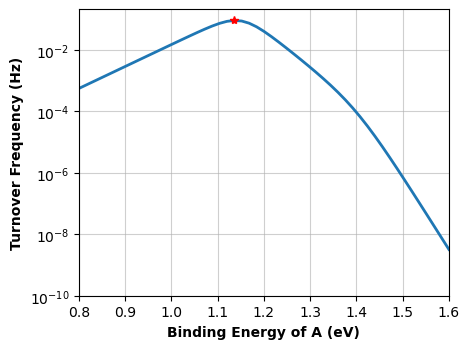

In [6]:
width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
ax.semilogy(Offsets,ystaticBg, linewidth = 2)
ax.plot([sX],[sy],'r*')

ax.set_xlabel('Binding Energy of A (eV)', weight = 'semibold', size = 10)
ax.set_ylabel('Turnover Frequency (Hz)', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim([0.8,1.6])
ax.set_ylim([1e-10,None])
ax.grid(alpha = 0.6)
fig.tight_layout()

fig.savefig('SabatierPlot.eps')

In [7]:
n = 6
Amplist = np.linspace(0.0,1.0,n)
DClist = np.linspace(0,1,n)

ebounds = np.array([[0.8],[2]]).reshape(2)

dcn = ProCatModel(BEParams,EaParams)
dcn.SetEnergyParams(ebounds,ns,'Square')

EFlist = np.zeros([n,n])
for j in range(n):
    for i in range(n):
        eparams = {'Amplitude':[Amplist[j]],
                       'DutyCycle':[DClist[i]],
                       'Frequency':[1e3],
                       'Offset':1.1,
                       }
        
        dcn.SetSignalParams(eparams,False)
        dcn.solveBVP(250)
        #dcn.printSimResults()
        #print(dcn.calc_TOF(dcn.CBg))
        EFlist[j,i] = (dcn.calc_TOF(dcn.CBg)/sy)

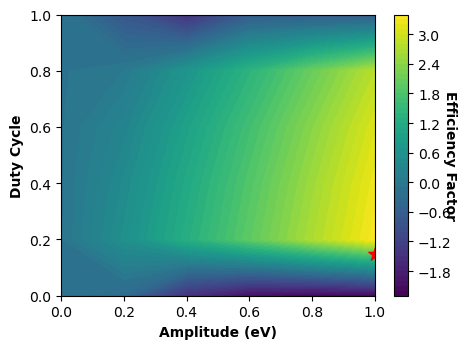

In [8]:
Ampmesh, DCmesh = np.meshgrid(Amplist,DClist)

width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
#c = ax.contourf(1.4*np.ones([n,n])+Ampmesh/2,DCmesh,np.log10(EFlist), levels = 64)
c = ax.contourf(Ampmesh,DCmesh,np.log10(EFlist).T, levels = 64)
ax.scatter([1.0],[0.15],color = 'r', marker = '*', s = 100)
cb = fig.colorbar(c)
cb.ax.tick_params(labelsize=10)
cb.set_label('Efficiency Factor', rotation=270, weight = 'semibold', size = 10)
#ax.set_title('Logarithmic Efficiency Factor')
ax.set_xlabel('Amplitude (eV)', weight = 'semibold', size = 10)
ax.set_ylabel('Duty Cycle', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)
#ax.tick_params(axis='both', which='major', labelsize=14)
fig.tight_layout()
fig.savefig('ABHeatmap.png')

In [9]:
n = 11
S1list = np.linspace(0.8,1.6,n)
S2list = np.linspace(0.8,1.6,n)

ebounds = np.array([[0.8],[1.6]]).reshape(2)

dcn = ProCatModel(BEParams,EaParams)
dcn.SetEnergyParams(ebounds,ns,'Square')

EFlist = np.zeros([n,n])
for j in range(n):
    for i in range(n):
        eparams = {'Amplitude':[(S1list[j]-S2list[i])/2],
                       'DutyCycle':[0.5],
                       'Frequency':[1e3],
                       'Offset':(S1list[j]+S2list[i])/2,
                       }
        
        dcn.SetSignalParams(eparams,False)
        dcn.solveBVP(250)
        #dcn.printSimResults()
        #print(dcn.calc_TOF(dcn.CBg))
        EFlist[j,i] = (dcn.calc_TOF(dcn.CBg)/sy)

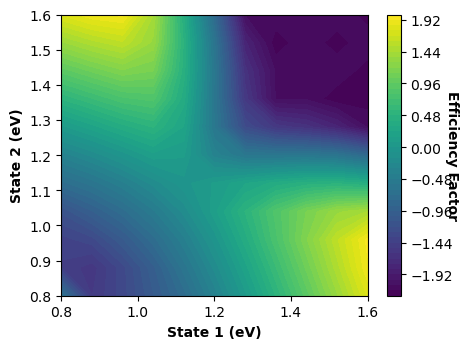

In [10]:
S1mesh, S2mesh = np.meshgrid(S1list,S2list)

width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
#c = ax.contourf(1.4*np.ones([n,n])+Ampmesh/2,DCmesh,np.log10(EFlist), levels = 64)
c = ax.contourf(S1mesh,S2mesh,np.log10(EFlist).T, levels = 64)
cb = fig.colorbar(c)
cb.ax.tick_params(labelsize=10)
cb.set_label('Efficiency Factor', rotation=270, weight = 'semibold', size = 10)
#ax.set_title('Logarithmic Efficiency Factor')
ax.set_xlabel('State 1 (eV)', weight = 'semibold', size = 10)
ax.set_ylabel('State 2 (eV)', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
#ax.tick_params(axis='both', which='major', labelsize=14)
fig.savefig('ABStatesHeatmap.png')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


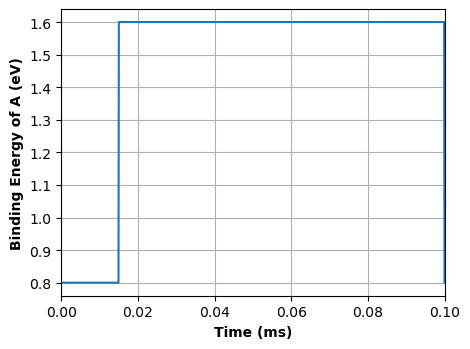

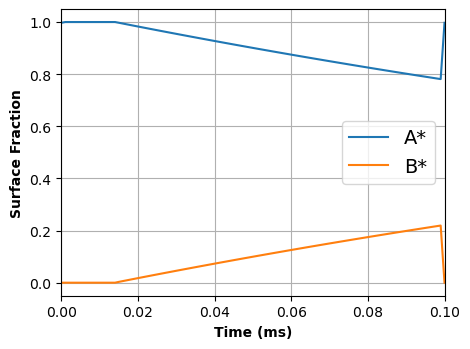

In [11]:
ebounds = np.array([[0.8],[1.6]]).reshape(2)

dcn = ProCatModel(BEParams,EaParams)
dcn.SetEnergyParams(ebounds,ns,'Square')

eparams = {'Amplitude':[1.0],
               'DutyCycle':[0.15],
               'Frequency':[1e3],
               'Offset':1.1,
               }

dcn.SetSignalParams(eparams,False)
dcn.solveBVP(100)

_, Eplot = dcn.EnergyProgram(np.linspace(0,1,1001))

width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
ax.plot(np.linspace(0,1,1001)/1e4*1e3,Eplot)
ax.set_xlim(0,0.10)
ax.grid()
ax.set_xlabel('Time (ms)', weight = 'semibold', size = 10)
ax.set_ylabel('Binding Energy of A (eV)', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
plt.savefig('ABEnergy.eps')

width = 4.8
fig, ax = plt.subplots(figsize = (width,width*.75))
ax.plot(dcn.tdata/1e4*1e3,dcn.CA)
ax.plot(dcn.tdata/1e4*1e3,dcn.CB)
ax.set_xlim(0,0.10)
ax.legend(['A*','B*'],fontsize = 14)
ax.grid()
ax.set_xlabel('Time (ms)', weight = 'semibold', size = 10)
ax.set_ylabel('Surface Fraction', weight = 'semibold', size = 10)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
plt.savefig('ABSurface.eps')